
# 05_Interpretation

This notebook interprets the results of the two required research questions separately.

## 1. Research Questions

### Proportion Analysis
Is the proportion of students who felt sad or hopeless different from 0.30?

**中文：**  
YRBS 2007 資料中，感到 sad or hopeless 的學生比例是否與 0.30 不同？

### Mean Analysis
Is the mean weight of students different from 68.0 kg?

**中文：**  
YRBS 2007 資料中，學生平均體重是否與 68.0 公斤不同？



## 2. Load Required Data and Files

This notebook reads:
- the original dataset `YRBS_2007.csv`
- the processed dataset `cycle2_vddc_imputed.csv`
- selected tables and figures from previous notebooks only when needed

The benchmark values used in this project are:
- `SadOrHopeless: p0 = 0.30`
- `HowMuchDoYouWeighWithoutShoesInKG: μ0 = 68.0`


In [11]:

import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Paths
raw_path = "../data/raw/YRBS_2007.csv"
processed_path = "../data/processed/cycle2_vddc_imputed.csv"
tables_dir = "../outputs/tables"
figures_dir = "../outputs/figures"

# Required data
raw_df = pd.read_csv(raw_path)
processed_df = pd.read_csv(processed_path)

# Benchmarks
p0 = 0.30
mu0 = 68.0

print("Raw data shape:", raw_df.shape)
print("Processed data shape:", processed_df.shape)
print("Benchmark p0:", p0)
print("Benchmark mu0:", mu0)


Raw data shape: (14041, 103)
Processed data shape: (14041, 2)
Benchmark p0: 0.3
Benchmark mu0: 68.0


## 3. Helper Functions

In [12]:

def safe_read_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path)
    print(f"File not found: {path}")
    return None

def show_table_if_exists(filename, title=None):
    path = os.path.join(tables_dir, filename)
    df = safe_read_csv(path)
    if df is not None:
        if title:
            display(Markdown(f"### {title}"))
        display(df)
    return df

def show_figure_if_exists(filename, title=None, width=700):
    path = os.path.join(figures_dir, filename)
    if os.path.exists(path):
        if title:
            display(Markdown(f"### {title}"))
        display(Image(filename=path, width=width))
        return True
    print(f"Figure not found: {path}")
    return False


def first_existing(row, keys, default=None):
    for key in keys:
        if key in row.index:
            value = row.get(key, default)
            if value is not None and not pd.isna(value):
                return value
    return default

def fmt_num(x, digits=4):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def fmt_int(x):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        return str(int(float(x)))
    except Exception:
        return str(x)

def decision_evidence_text(decision):
    if decision is None or pd.isna(decision):
        return "unclear because the decision value is not available"
    d = str(decision).strip().lower()
    if "not reject" in d or "fail to reject" in d:
        return "not enough"
    if "reject" in d:
        return "enough"
    return "unclear"



## 4. Proportion Analysis Interpretation

This section discusses only the first research question:

**Is the proportion of students who felt sad or hopeless different from 0.30?**  
**中文：YRBS 2007 資料中，感到 sad or hopeless 的學生比例是否與 0.30 不同？**


In [13]:

# Read only the proportion-related tables that are needed
prop_sample = show_table_if_exists("proportion_sample_summary.csv", "Proportion Sample Summary")
prop_benchmark = show_table_if_exists("proportion_benchmark_table.csv", "Proportion Benchmark")
prop_ci = show_table_if_exists("proportion_confidence_interval.csv", "Proportion Confidence Interval")
prop_test = show_table_if_exists("proportion_hypothesis_test.csv", "Proportion Hypothesis Test")
prop_summary = show_table_if_exists("proportion_inference_summary.csv", "Proportion Inference Summary")


### Proportion Sample Summary

,measure,value
0,sample_size_n,14041.00000
1,success_count,4205.00000
2,failure_count,9836.00000
3,sample_proportion_p_hat,0.29948


### Proportion Benchmark

,parameter,benchmark_p0
0,population_proportion_p,0.3


### Proportion Confidence Interval

,confidence_level,p_hat,standard_error,z_critical,margin_of_error,ci_lower,ci_upper
0,0.95,0.29948,0.003865,1.959964,0.007576,0.291904,0.307056


### Proportion Hypothesis Test

,null_hypothesis,alternative_hypothesis,sample_proportion_p_hat,benchmark_p0,standard_error_under_H0,z_statistic,p_value,alpha,decision
0,p = 0.30,p != 0.30,0.29948,0.3,0.003867,-0.134436,0.893058,0.05,Do not reject H0


### Proportion Inference Summary

,analysis,variable,sample_size_n,sample_proportion_p_hat,benchmark_p0,confidence_level,ci_lower,ci_upper,z_statistic,p_value,decision
0,Proportion Analysis,SadOrHopeless,14041,0.29948,0.3,0.95,0.291904,0.307056,-0.134436,0.893058,Do not reject H0


### Behavior EDA: Original Code Frequencies

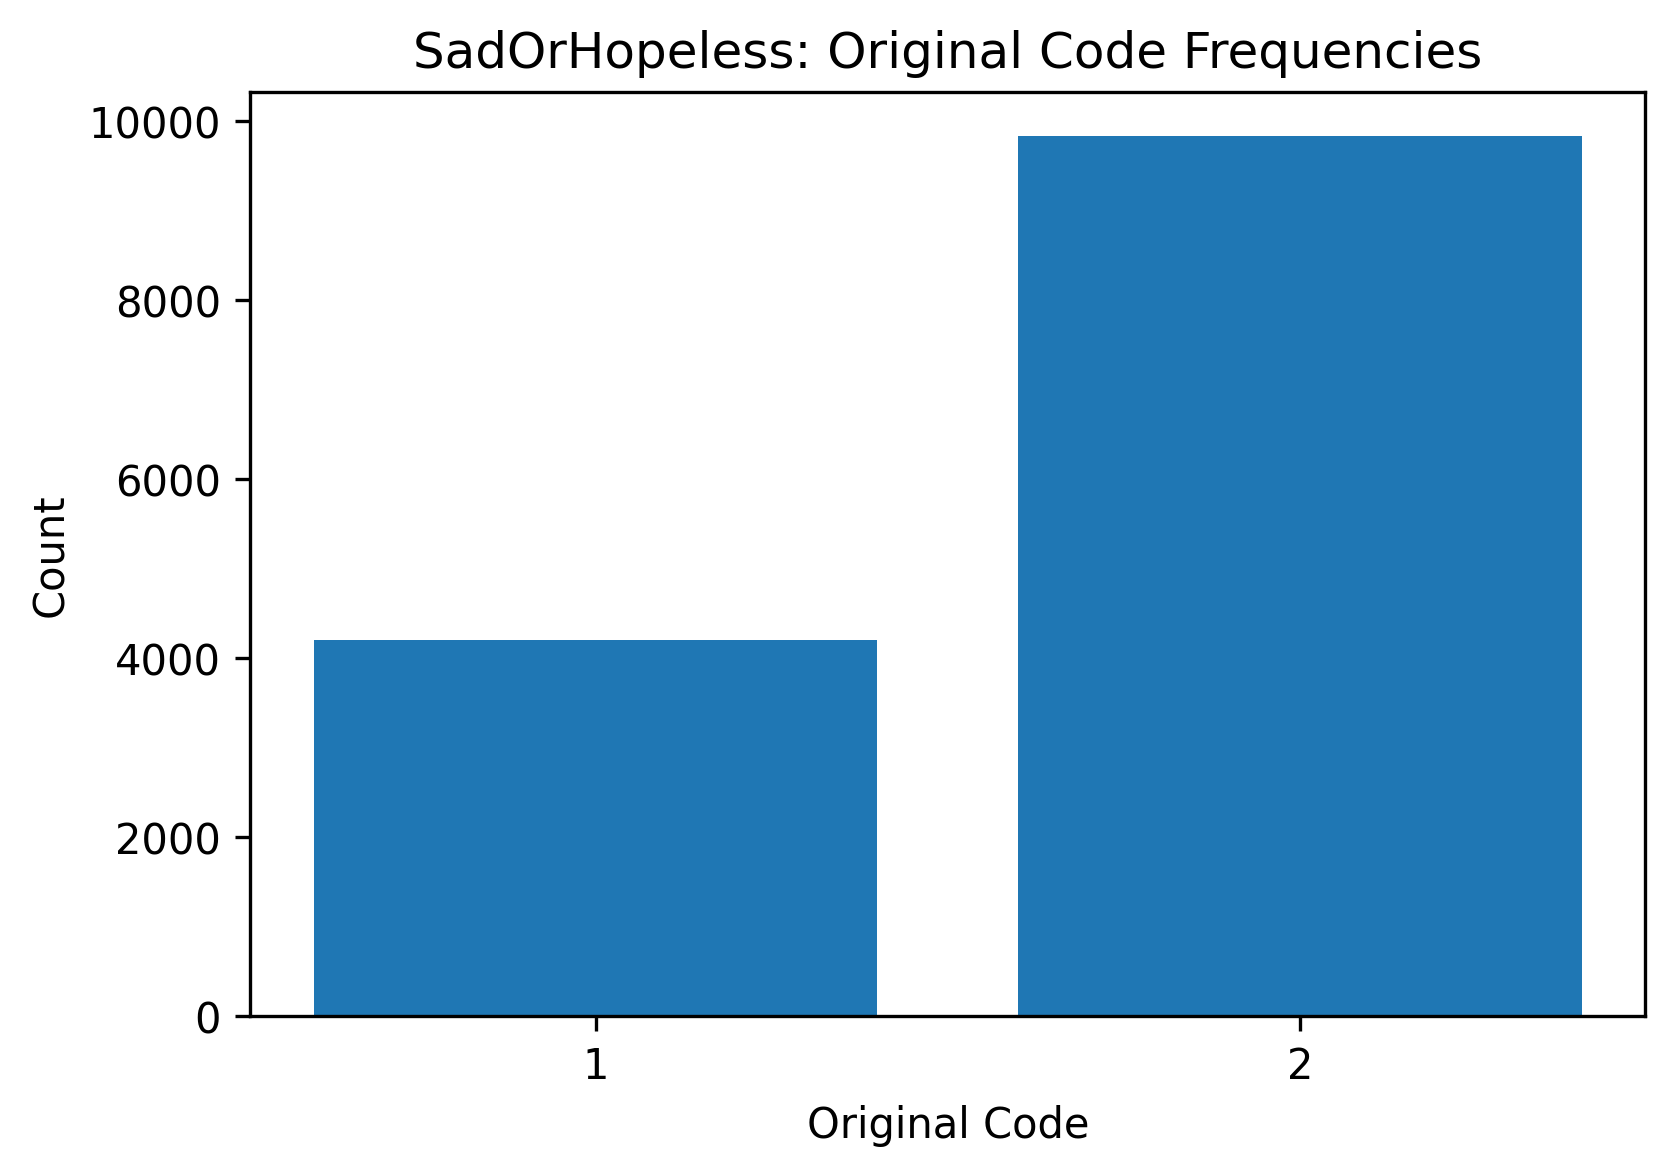

### Behavior Additional EDA: Success and Failure Proportions

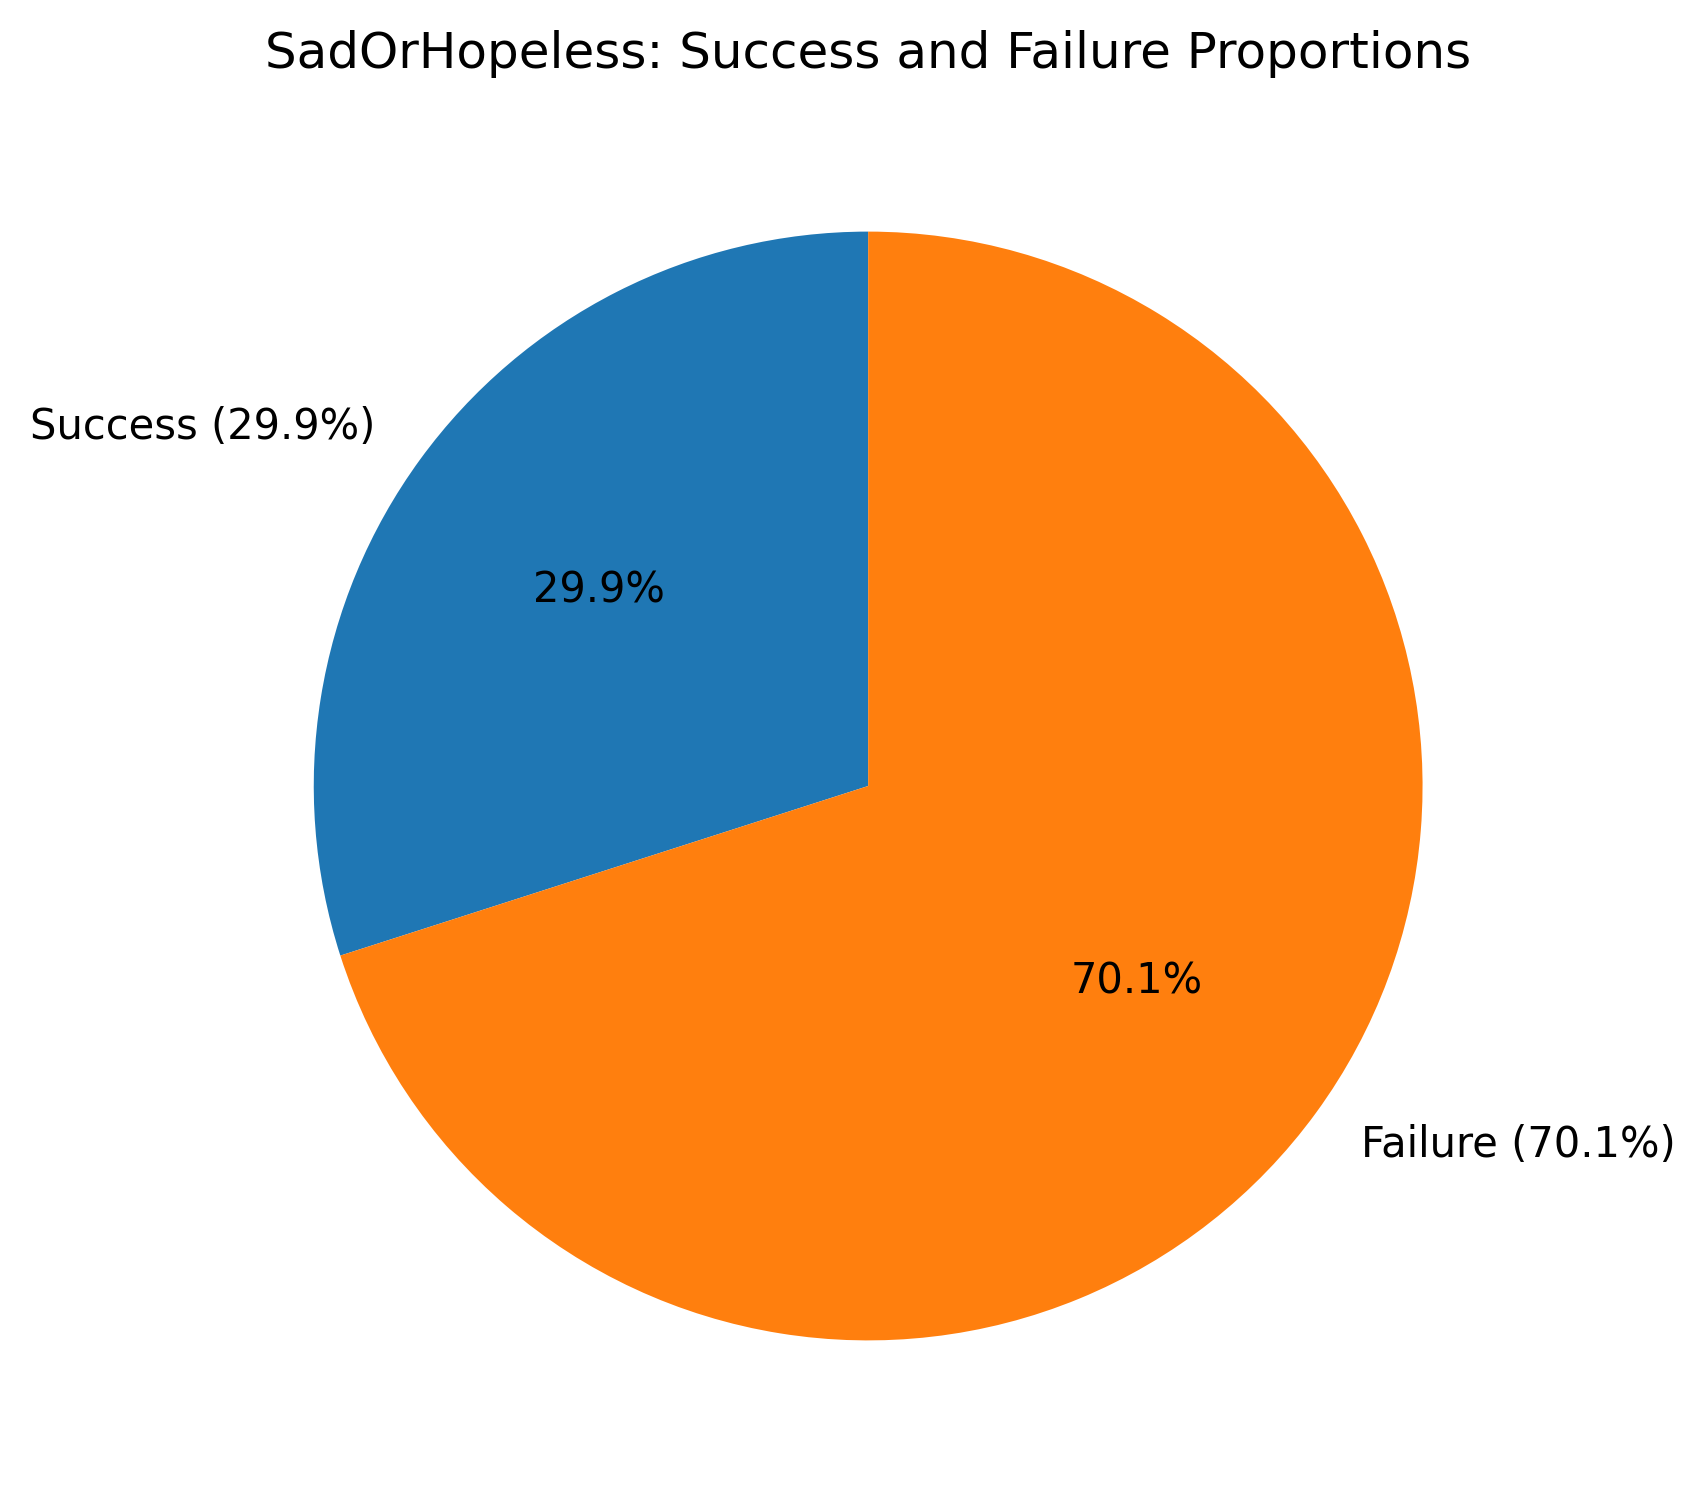

### Behavior Data Quality Overview

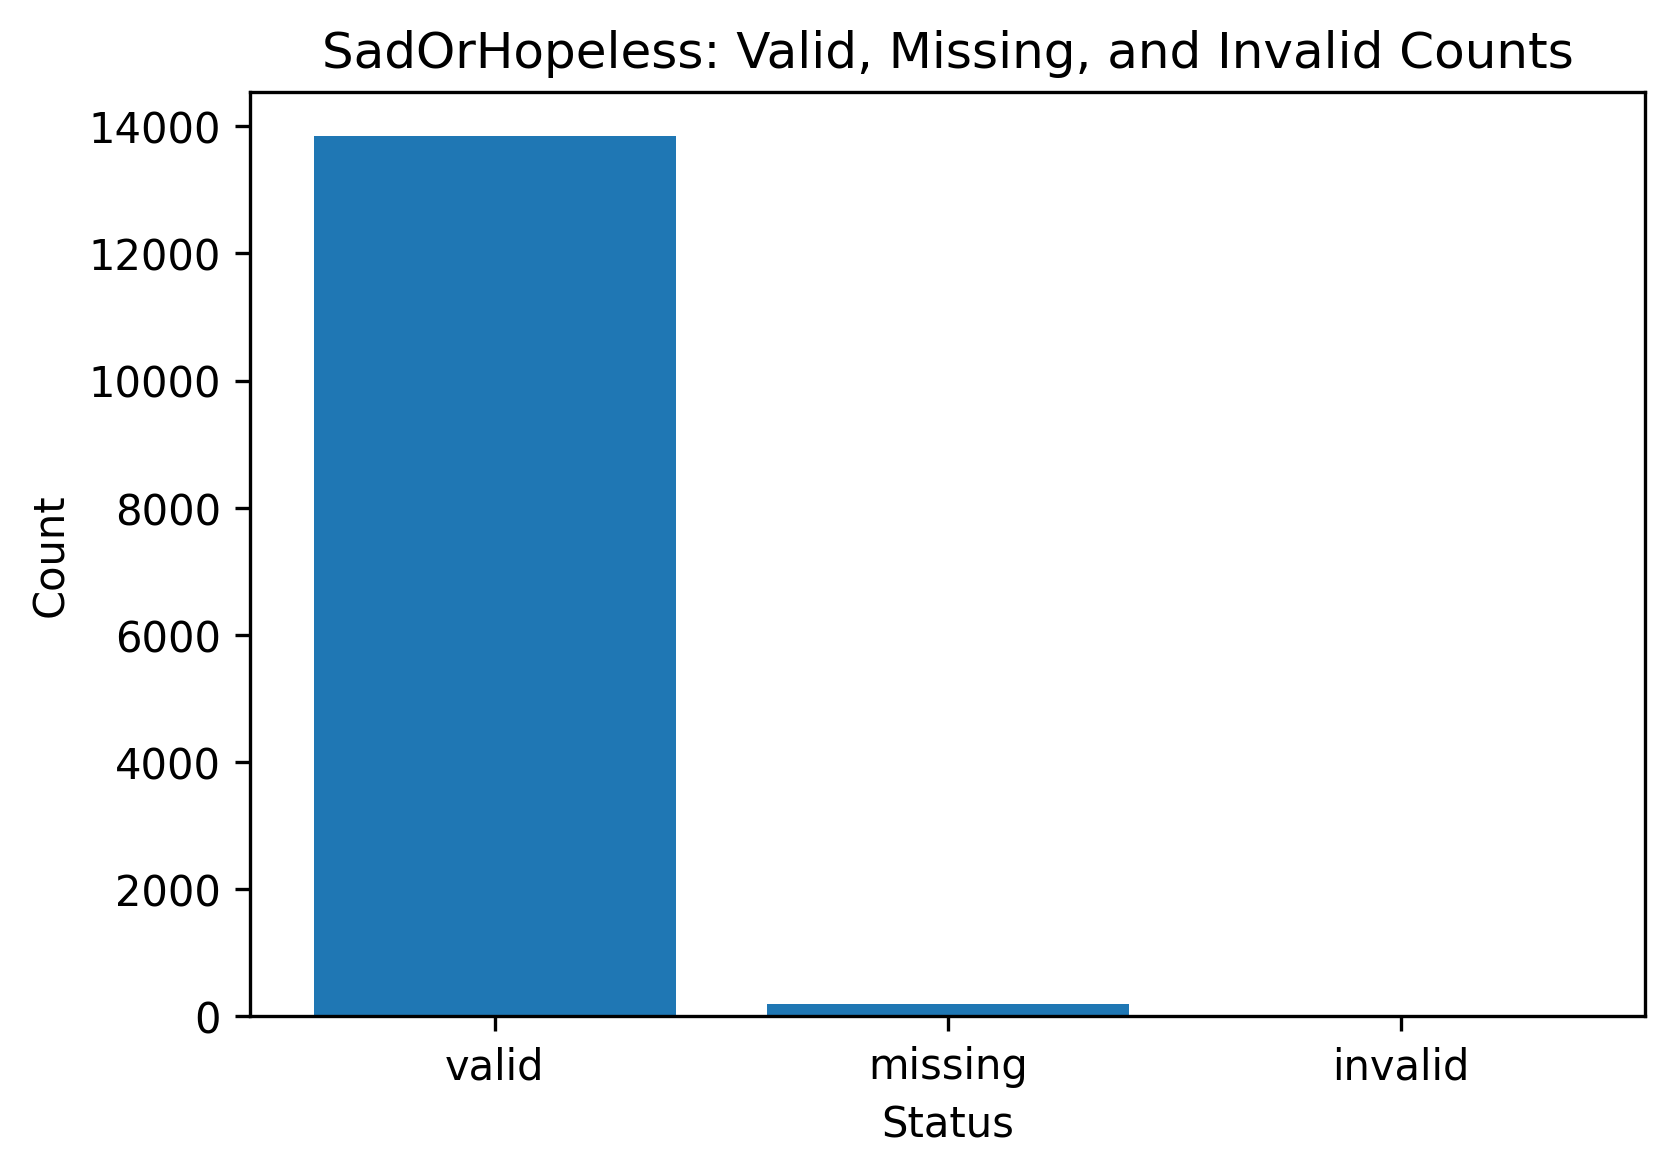

True

In [14]:

# Show only the most useful behavior EDA figures
show_figure_if_exists("behavior_original_code_frequencies.png", "Behavior EDA: Original Code Frequencies")
show_figure_if_exists("behavior_success_failure_pie.png", "Behavior Additional EDA: Success and Failure Proportions")
show_figure_if_exists("behavior_missing_invalid_valid.png", "Behavior Data Quality Overview")


In [15]:

# Build a compact interpretation draft for the proportion analysis
if prop_sample is not None and prop_ci is not None and prop_test is not None:
    # proportion_sample_summary.csv has columns: measure, value
    sample_prop = None
    sample_n = None

    if set(["measure", "value"]).issubset(prop_sample.columns):
        measure_map = dict(zip(prop_sample["measure"], prop_sample["value"]))
        sample_n = measure_map.get("sample_size_n", None)
        sample_prop = measure_map.get("sample_proportion_p_hat", None)
    else:
        sample_row = prop_sample.iloc[0]
        sample_prop = first_existing(sample_row, [
            "sample_proportion_p_hat", "sample_proportion", "p_hat", "estimate"
        ])
        sample_n = first_existing(sample_row, [
            "sample_size_n", "sample_size", "n"
        ])

    ci_row = prop_ci.iloc[0]
    test_row = prop_test.iloc[0]

    ci_lower = first_existing(ci_row, ["ci_lower", "lower_bound", "lower_ci"])
    ci_upper = first_existing(ci_row, ["ci_upper", "upper_bound", "upper_ci"])

    z_stat = first_existing(test_row, ["z_statistic", "test_statistic", "z_value"])
    p_value = first_existing(test_row, ["p_value", "pvalue"])
    decision = first_existing(test_row, ["decision", "test_decision", "result"])

    decision_text = str(decision) if decision is not None else "N/A"
    evidence_text = "enough" if "reject" in decision_text.lower() else "not enough"

    prop_final_summary = f'''
### Proportion Interpretation Draft

**Research Question**  
Is the proportion of students who felt sad or hopeless different from **{fmt_num(p0, 2)}**?

**中文：**  
YRBS 2007 資料中，感到 sad or hopeless 的學生比例是否與 **{fmt_num(p0, 2)}** 不同？

**What was estimated or tested**  
We estimated the population proportion of students who felt sad or hopeless and tested whether this proportion is different from the benchmark value **p0 = {fmt_num(p0, 2)}**.

**Main numerical results**  
The sample proportion was approximately **{fmt_num(sample_prop, 4)}**, based on a final sample size of **{fmt_int(sample_n)}**.  
The 95% confidence interval was approximately **({fmt_num(ci_lower, 4)}, {fmt_num(ci_upper, 4)})**.  
The one-sample proportion test produced a test statistic of approximately **{fmt_num(z_stat, 4)}** with a p-value of **{fmt_num(p_value, 4)}**.

**What the confidence interval means**  
This confidence interval gives a plausible range for the true population proportion of students who felt sad or hopeless in the YRBS 2007 sample context. If this study were repeated many times, similarly constructed intervals would capture the true population proportion about 95% of the time.

**What the hypothesis test implies**  
Using the benchmark value **0.30**, the hypothesis test result was: **{decision_text}**. This means the sample provides **{evidence_text}** evidence that the true population proportion is different from **0.30**.

**Whether the inferential result is consistent with what we saw in EDA**  
The behavior EDA showed the original code frequencies, the binary recoding outcome, the success/failure composition, and the missing or invalid value count. The inferential result should be interpreted together with those EDA displays to confirm whether the observed sample proportion visually appears above, below, or close to the benchmark.

**What should be interpreted cautiously**  
The result depends on the coding rule, the handling of missing or invalid values, and the assumption that the sample is appropriate for this inferential procedure.
    '''
    display(Markdown(prop_final_summary))
else:
    print("Proportion inference tables are not fully available.")



### Proportion Interpretation Draft

**Research Question**  
Is the proportion of students who felt sad or hopeless different from **0.30**?

**中文：**  
YRBS 2007 資料中，感到 sad or hopeless 的學生比例是否與 **0.30** 不同？

**What was estimated or tested**  
We estimated the population proportion of students who felt sad or hopeless and tested whether this proportion is different from the benchmark value **p0 = 0.30**.

**Main numerical results**  
The sample proportion was approximately **0.2995**, based on a final sample size of **14041**.  
The 95% confidence interval was approximately **(0.2919, 0.3071)**.  
The one-sample proportion test produced a test statistic of approximately **-0.1344** with a p-value of **0.8931**.

**What the confidence interval means**  
This confidence interval gives a plausible range for the true population proportion of students who felt sad or hopeless in the YRBS 2007 sample context. If this study were repeated many times, similarly constructed intervals would capture the true population proportion about 95% of the time.

**What the hypothesis test implies**  
Using the benchmark value **0.30**, the hypothesis test result was: **Do not reject H0**. This means the sample provides **enough** evidence that the true population proportion is different from **0.30**.

**Whether the inferential result is consistent with what we saw in EDA**  
The behavior EDA showed the original code frequencies, the binary recoding outcome, the success/failure composition, and the missing or invalid value count. The inferential result should be interpreted together with those EDA displays to confirm whether the observed sample proportion visually appears above, below, or close to the benchmark.

**What should be interpreted cautiously**  
The result depends on the coding rule, the handling of missing or invalid values, and the assumption that the sample is appropriate for this inferential procedure.
    


## 5. Mean Analysis Interpretation

This section discusses only the second research question:

**Is the mean weight of students different from 68.0 kg?**  
**中文：YRBS 2007 資料中，學生平均體重是否與 68.0 公斤不同？**


In [16]:

# Read only the mean-related tables that are needed
mean_sample = show_table_if_exists("mean_sample_summary.csv", "Mean Sample Summary")
mean_benchmark = show_table_if_exists("mean_benchmark_table.csv", "Mean Benchmark")
mean_ci = show_table_if_exists("mean_confidence_interval.csv", "Mean Confidence Interval")
mean_test = show_table_if_exists("mean_hypothesis_test.csv", "Mean Hypothesis Test")
mean_summary = show_table_if_exists("mean_inference_summary.csv", "Mean Inference Summary")
continuous_summary = show_table_if_exists("continuous_summary_statistics.csv", "Continuous EDA Summary Statistics")
continuous_outlier = show_table_if_exists("continuous_outlier_summary.csv", "Continuous EDA Outlier Summary")


### Mean Sample Summary

,variable,sample_size_n,sample_mean,sample_std_dev
0,HowMuchDoYouWeighWithoutShoesInKG,14041,68.555508,17.042366


### Mean Benchmark

,variable,benchmark_mean_mu0,units
0,HowMuchDoYouWeighWithoutShoesInKG,68.0,kg


### Mean Confidence Interval

...

,research_question,estimate_summary,confidence_interval_interpretation,hypothesis_test_interpretation,context_conclusion
0,Is the mean weight of students different from ...,The sample mean weight is 68.556 kg based on n...,A 95% confidence interval for the population m...,"The one-sample t-test gives t = 3.862, df = 14...","In context, this means the average student wei..."


### Continuous EDA Summary Statistics

,statistic,value
0,sample_size,14041.0000
1,mean,68.5555
2,median,65.3200
3,standard_deviation,17.0424
4,minimum,34.4700
5,Q1,56.7000
6,Q2_median,65.3200
7,Q3,77.1100
8,maximum,180.9900


### Continuous EDA Outlier Summary

,metric,value
0,Q1,56.700
1,Q3,77.110
2,IQR,20.410
3,lower_bound,26.085
4,upper_bound,107.725
5,outlier_count,484.000


### Continuous EDA: Histogram of Weight

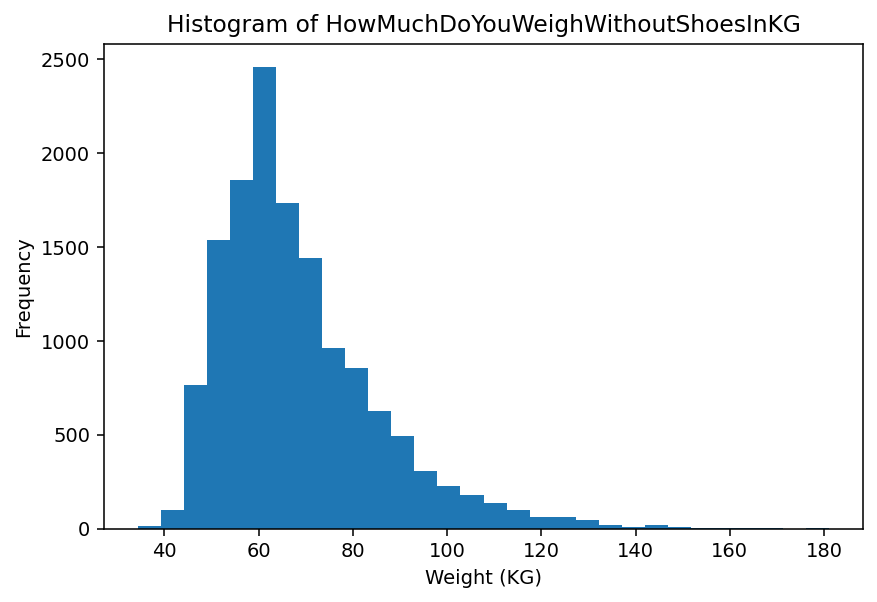

### Continuous EDA: Boxplot of Weight

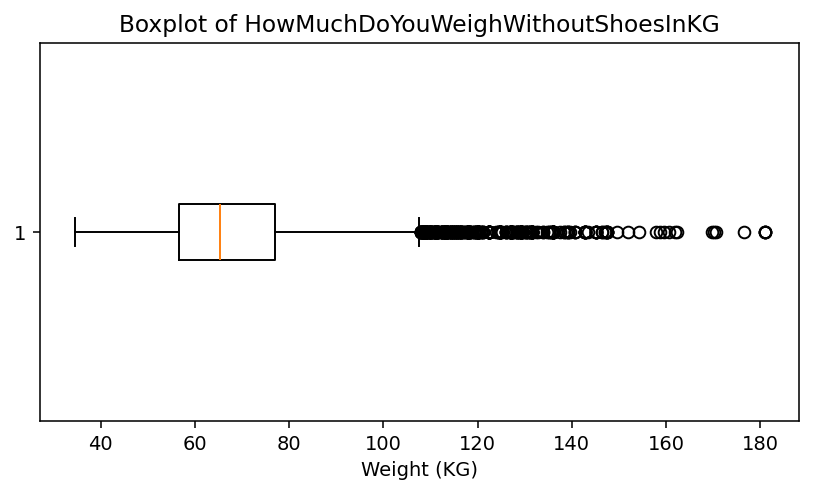

### Continuous Additional EDA: ECDF of Weight

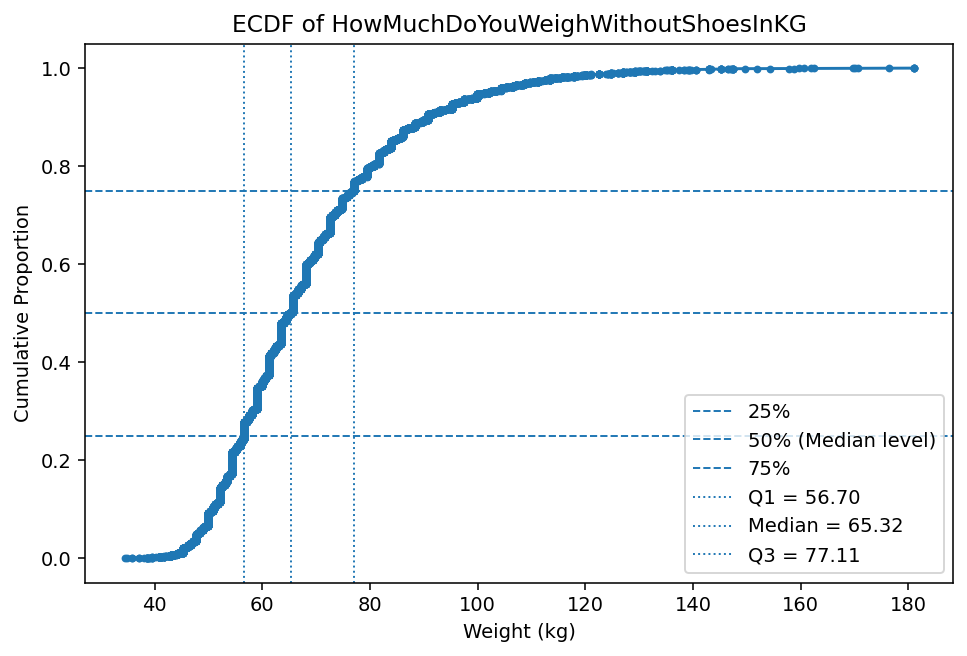

True

In [17]:

# Show only the most useful continuous EDA figures
show_figure_if_exists("continuous_histogram.png", "Continuous EDA: Histogram of Weight")
show_figure_if_exists("continuous_boxplot.png", "Continuous EDA: Boxplot of Weight")
show_figure_if_exists("continuous_ecdf_weight.png", "Continuous Additional EDA: ECDF of Weight")


In [18]:

# Build a compact interpretation draft for the mean analysis
if mean_sample is not None and mean_ci is not None and mean_test is not None:
    sample_row = mean_sample.iloc[0]
    ci_row = mean_ci.iloc[0]
    test_row = mean_test.iloc[0]

    n = first_existing(sample_row, ["sample_size_n", "sample_size", "n"])
    xbar = first_existing(sample_row, ["sample_mean", "mean", "xbar"])
    s = first_existing(sample_row, ["sample_std_dev", "sample_std", "standard_deviation", "std", "s"])

    ci_lower = first_existing(ci_row, ["ci_lower", "lower_bound", "lower_ci"])
    ci_upper = first_existing(ci_row, ["ci_upper", "upper_bound", "upper_ci"])

    t_stat = first_existing(test_row, ["test_statistic_t", "t_statistic", "test_statistic", "t_value"])
    p_value = first_existing(test_row, ["p_value", "pvalue"])
    decision = first_existing(test_row, ["decision", "test_decision", "result"])

    decision_text = str(decision) if decision is not None else "N/A"
    evidence_text = "enough" if "reject" in decision_text.lower() else "not enough"

    mean_final_summary = f'''
### Mean Interpretation Draft

**Research Question**  
Is the mean weight of students different from **{fmt_num(mu0, 1)} kg**?

**中文：**  
YRBS 2007 資料中，學生平均體重是否與 **{fmt_num(mu0, 1)} 公斤** 不同？

**What was estimated or tested**  
We estimated the population mean of `HowMuchDoYouWeighWithoutShoesInKG` and tested whether it is different from the benchmark value **μ0 = {fmt_num(mu0, 1)}**.

**Main numerical results**  
The sample size was **{fmt_int(n)}**, the sample mean was **{fmt_num(xbar, 4)} kg**, and the sample standard deviation was **{fmt_num(s, 4)}**.  
The 95% confidence interval was approximately **({fmt_num(ci_lower, 4)}, {fmt_num(ci_upper, 4)})**.  
The one-sample t-test produced a test statistic of approximately **{fmt_num(t_stat, 4)}** with a p-value of **{fmt_num(p_value, 4)}**.

**What the confidence interval means**  
This confidence interval gives a plausible range for the true population mean weight in the YRBS 2007 sample context. If this study were repeated many times, similarly constructed intervals would capture the true population mean about 95% of the time.

**What the hypothesis test implies**  
Using the benchmark value **68.0 kg**, the hypothesis test result was: **{decision_text}**. This means the sample provides **{evidence_text}** evidence that the true population mean is different from **68.0 kg**.

**Whether the inferential result is consistent with what we saw in EDA**  
The continuous EDA described the sample size, center, spread, quartiles, histogram shape, boxplot pattern, possible outliers, and the ECDF pattern. The inferential result should be interpreted together with those EDA findings to see whether the sample mean visually appears close to or different from the benchmark.

**What should be interpreted cautiously**  
The result should be interpreted carefully because the weight variable may contain extreme values, and the final outcome also depends on the treatment of missing or invalid values.
    '''
    display(Markdown(mean_final_summary))
else:
    print("Mean inference tables are not fully available.")



### Mean Interpretation Draft

**Research Question**  
Is the mean weight of students different from **68.0 kg**?

**中文：**  
YRBS 2007 資料中，學生平均體重是否與 **68.0 公斤** 不同？

**What was estimated or tested**  
We estimated the population mean of `HowMuchDoYouWeighWithoutShoesInKG` and tested whether it is different from the benchmark value **μ0 = 68.0**.

**Main numerical results**  
The sample size was **14041**, the sample mean was **68.5555 kg**, and the sample standard deviation was **17.0424**.  
The 95% confidence interval was approximately **(68.2736, 68.8374)**.  
The one-sample t-test produced a test statistic of approximately **3.8624** with a p-value of **0.0001**.

**What the confidence interval means**  
This confidence interval gives a plausible range for the true population mean weight in the YRBS 2007 sample context. If this study were repeated many times, similarly constructed intervals would capture the true population mean about 95% of the time.

**What the hypothesis test implies**  
Using the benchmark value **68.0 kg**, the hypothesis test result was: **Reject H0**. This means the sample provides **enough** evidence that the true population mean is different from **68.0 kg**.

**Whether the inferential result is consistent with what we saw in EDA**  
The continuous EDA described the sample size, center, spread, quartiles, histogram shape, boxplot pattern, possible outliers, and the ECDF pattern. The inferential result should be interpreted together with those EDA findings to see whether the sample mean visually appears close to or different from the benchmark.

**What should be interpreted cautiously**  
The result should be interpreted carefully because the weight variable may contain extreme values, and the final outcome also depends on the treatment of missing or invalid values.
    


## 6. Final Synthesis

This final synthesis connects:
- the research questions
- the main EDA findings
- the inferential results
- the final conclusions


In [19]:

final_text = f'''
### Final Synthesis

## 1. Research Questions

### Proportion Analysis
Is the proportion of students who felt sad or hopeless different from 0.30?

**中文：**  
YRBS 2007 資料中，感到 sad or hopeless 的學生比例是否與 0.30 不同？

### Mean Analysis
Is the mean weight of students different from 68.0 kg?

**中文：**  
YRBS 2007 資料中，學生平均體重是否與 68.0 公斤不同？

**Connection to EDA**  
For `SadOrHopeless`, the EDA described the original code distribution, the binary recoding outcome, the success/failure structure, the pie-chart proportion view, and the data quality pattern.  
For `HowMuchDoYouWeighWithoutShoesInKG`, the EDA described the sample size, center, spread, quartiles, histogram shape, boxplot pattern, possible outliers, and cumulative distribution pattern through the ECDF.

**Connection to Inference**  
The proportion analysis estimated the sample proportion and tested it against **p0 = {fmt_num(p0, 2)}**.  
The mean analysis estimated the sample mean and tested it against **μ0 = {fmt_num(mu0, 1)} kg**.

**Final Conclusion**  
The final conclusion should combine the research questions, the main EDA patterns, and the inferential results. In your final edited version, make sure the wording of the conclusion matches the actual numerical results and decisions shown above.
'''
display(Markdown(final_text))



### Final Synthesis

## 1. Research Questions

### Proportion Analysis
Is the proportion of students who felt sad or hopeless different from 0.30?

**中文：**  
YRBS 2007 資料中，感到 sad or hopeless 的學生比例是否與 0.30 不同？

### Mean Analysis
Is the mean weight of students different from 68.0 kg?

**中文：**  
YRBS 2007 資料中，學生平均體重是否與 68.0 公斤不同？

**Connection to EDA**  
For `SadOrHopeless`, the EDA described the original code distribution, the binary recoding outcome, the success/failure structure, the pie-chart proportion view, and the data quality pattern.  
For `HowMuchDoYouWeighWithoutShoesInKG`, the EDA described the sample size, center, spread, quartiles, histogram shape, boxplot pattern, possible outliers, and cumulative distribution pattern through the ECDF.

**Connection to Inference**  
The proportion analysis estimated the sample proportion and tested it against **p0 = 0.30**.  
The mean analysis estimated the sample mean and tested it against **μ0 = 68.0 kg**.

**Final Conclusion**  
The final conclusion should combine the research questions, the main EDA patterns, and the inferential results. In your final edited version, make sure the wording of the conclusion matches the actual numerical results and decisions shown above.


In [20]:
# Save one TXT summary for each research question and its conclusion
summary_dir="../outputs/summary"
os.makedirs(summary_dir, exist_ok=True)

prop_txt_path = os.path.join(summary_dir, "final_summary_Proportion.txt")
mean_txt_path = os.path.join(summary_dir, "final_summary_Mean.txt")

if "prop_final_summary" in globals():
    with open(prop_txt_path, "w", encoding="utf-8") as f:
        f.write(prop_final_summary.strip())
    print(f"Saved: {prop_txt_path}")
else:
    print("Proportion summary text was not generated.")

if "mean_final_summary" in globals():
    with open(mean_txt_path, "w", encoding="utf-8") as f:
        f.write(mean_final_summary.strip())
    print(f"Saved: {mean_txt_path}")
else:
    print("Mean summary text was not generated.")


Saved: ../outputs/summary\final_summary_Proportion.txt
Saved: ../outputs/summary\final_summary_Mean.txt



## 7. Submission Reminder

Before submission, make sure:
- both research questions are clearly shown
- the two analyses are discussed separately
- the benchmark values `p0 = 0.30` and `μ0 = 68.0` are clearly used
- EDA and inference are connected in the interpretation
- all conclusions are written in context
